
# **Predicting Streamflow for the 10 chosen Ungauged Catchments**
**Overview**

This notebook applies the best performing  (architecture -hidden size 128) pre-trained Long Short-Term Memory (LSTM) rainfall-runoff model to predict daily streamflow for the 10 selected ungauged catchments in the CAMELS-DE dataset.

The trained model uses: Daily mean precipitation and
Daily mean temperature to predict: Daily streamflow (mm/day)

The model architecture and trained weights were obtained from the previously trained regional LSTM. Therefore, no training is performed in this notebook. Instead, the workflow focuses on preparing new catchment data, applying the trained model, generating predictions, and exporting the results for analysis and comparison.

**Workflow**

1.	Install and import the required libraries.
2.	Load the trained LSTM model.
3.	Load normalization statistics.
4.	Import ungauged catchment data.
5.	Standardize precipitation and temperature.
6.	Prepare 365-day input sequences.
7.	Generate streamflow predictions.
8.	Save predictions to Excel.
9.	Visualize predicted hydrographs.




In [ ]:
# Importing required libraries
import numpy as np
import pandas as pd
import tensorflow as tf

# Step 1: Loading the Pre-trained Regional LSTM Model

The trained model is loaded using:

config.json (model architecture)
model.weights.h5 (trained weights)

Model metadata are also loaded for reference.

In [ ]:
import tensorflow as tf
import json

# Load model architecture from config.json
with open('config.json', 'r') as f:
    model_config = f.read()
model = tf.keras.models.model_from_json(model_config)

# Load model weights from model.weights.h5
model.load_weights('model.weights.h5')

print("Model loaded successfully by combining architecture and weights.")

# Load and display metadata
with open('metadata.json', 'r') as f:
    metadata = json.load(f)

display(metadata)

Model loaded successfully by combining architecture and weights.


{'keras_version': '3.13.2', 'date_saved': '2026-07-13@23:43:45'}

# Step 2: Global Training Statistics

The LSTM was trained using globally standardized inputs.

These mean and standard deviation values are used to standardize the new precipitation and temperature data before prediction.

In [ ]:

# GLOBAL TRAINING STATISTICS

mean_p = 2.4686
std_p  = 4.9501

mean_t = 7.6704
std_t  = 7.4280

mean_q = 1.10666492
std_q  = 1.65701115

# Step 3: Importing Ungauged Catchment Data

The Excel workbook contains two sheets:

Precipitation
Temperature

Each sheet contains daily observations for the 10 ungauged catchments.

In [ ]:
file = "Ungauged_Catchments.xlsx"

precip = pd.read_excel(
    file,
    sheet_name="Precipitation"
)

temperature = pd.read_excel(
    file,
    sheet_name="Temperature"
)

Listing Available Catchments to confirm

Retrieve the names of all ungauged catchments from the dataset.

In [ ]:
catchments = precip.columns[1:]

print(catchments)

Index(['DE213450', 'DE210720', 'DE213560', 'DE110570', 'DEA11090', 'DE214090',
       'DE411220', 'DEA10160', 'DE810570', 'DEA10630'],
      dtype='object')


Preparing the Date Column

The Date column is converted into datetime format to enable chronological processing and plotting.

In [ ]:
precip["Date"] = pd.to_datetime(precip["Date"])
temperature["Date"] = pd.to_datetime(temperature["Date"])

# Step 4: Standardizing the Input Variables

Precipitation and temperature are standardized using the same statistics employed during model training.

This ensures consistency between training and prediction datasets.

In [ ]:
precip_std = precip.copy()
temperature_std = temperature.copy()

precip_std.iloc[:,1:] = (
    precip.iloc[:,1:] - mean_p
) / std_p

temperature_std.iloc[:,1:] = (
    temperature.iloc[:,1:] - mean_t
) / std_t

print("✓ Inputs standardized")

✓ Inputs standardized


# Step 5: Creating the LSTM Input Windows

The Regional LSTM uses 365 consecutive days of precipitation and temperature as input to predict the next day's streamflow.

In [ ]:
# Window length

WINDOW = 365

# Inputs precipitation and temperature
def create_windows(P, T, window):

    X = []

    for i in range(len(P) - window):

        p_window = P[i:i+window]

        t_window = T[i:i+window]

        X.append(
            np.column_stack(
                (p_window, t_window)
            )
        )

    return np.array(X, dtype=np.float32)

Testing the Model on One Catchment

A single catchment is processed first to verify that the model generates valid predictions.

In [ ]:
catchment = catchments[0]

P = precip_std[catchment].values
T = temperature_std[catchment].values

X = create_windows(P, T, WINDOW)

print(X.shape)

pred_std = model.predict(
    X,
    verbose=1 #shows processing progress
)

(25203, 365, 2)
788/788 ━━━━━━━━━━━━━━━━━━━━ 135s 172ms/step


# Converting the prediction Back to Streamflow Units

The model outputs standardized streamflow values.

These predictions are transformed back into mm/day.

In [ ]:
# Reverse standardization

pred_mm = pred_std.flatten() * std_q + mean_q

print(pred_mm[:10])

[1.4286953 1.6682923 1.4410505 1.5934875 1.4601074 1.9869002 1.3872428
 1.2220178 1.2884198 1.2511046]


# Step 6: Predicting Streamflow for All the 10 Ungauged Catchments

The trained LSTM is applied sequentially to every catchment contained in the Excel workbook.

In [ ]:
predictions = {}

for catchment in catchments:

    print(f"Running {catchment}")

    P = precip_std[catchment].values
    T = temperature_std[catchment].values

    X = create_windows(
        P,
        T,
        WINDOW
    )

    pred_std = model.predict(
        X,
        verbose=0
    )
# Reversing standardization
    pred_mm = (
        pred_std.flatten() * std_q
        + mean_q
    )

    predictions[catchment] = pred_mm

print("✓ All catchments completed")

Running DE213450
Running DE210720
Running DE213560
Running DE110570
Running DEA11090
Running DE214090
Running DE411220
Running DEA10160
Running DE810570
Running DEA10630
✓ All catchments completed


Organizing Predictions into a DataFrame

The predicted streamflow series for all catchments are combined into a single table with corresponding dates.

In [ ]:
prediction_df = pd.DataFrame()

prediction_df["Date"] = precip["Date"].iloc[WINDOW:].values

for catchment in catchments:

    prediction_df[catchment] = predictions[catchment]

prediction_df.head()

,Date,DE213450,DE210720,DE213560,DE110570,DEA11090,DE214090,DE411220,DEA10160,DE810570,DEA10630
0,1952-01-01,1.428695,0.835611,0.737693,1.725431,0.579937,0.994197,0.141671,1.782388,0.212453,1.669392
1,1952-01-02,1.668292,0.960276,0.717492,1.735626,0.690893,0.849697,0.169224,1.894233,0.337762,2.051988
2,1952-01-03,1.441051,0.894269,0.654649,2.078559,2.726303,0.890016,0.213462,4.395788,0.487628,5.444148
3,1952-01-04,1.593488,0.961420,0.633670,1.812595,1.961167,0.771671,0.222397,3.092449,0.387605,3.856015
4,1952-01-05,1.460107,0.936518,0.633202,1.714218,1.748894,0.743056,0.223030,2.653001,0.340476,3.536580


# Step 7: Exporting Predictions

The predicted daily streamflow for all ungauged catchments is saved to an Excel workbook for further analysis and comparisons

In [ ]:
output_file = "Ungauged_Streamflows_Predictions.xlsx"

prediction_df.to_excel(
    output_file,
    index=False
)

print("✓ Predictions saved")
print(output_file)

✓ Predictions saved
Ungauged_Streamflows_Predictions.xlsx


Visualizing a Predicted Hydrograph

A predicted hydrograph is plotted for the first ungauged catchment.

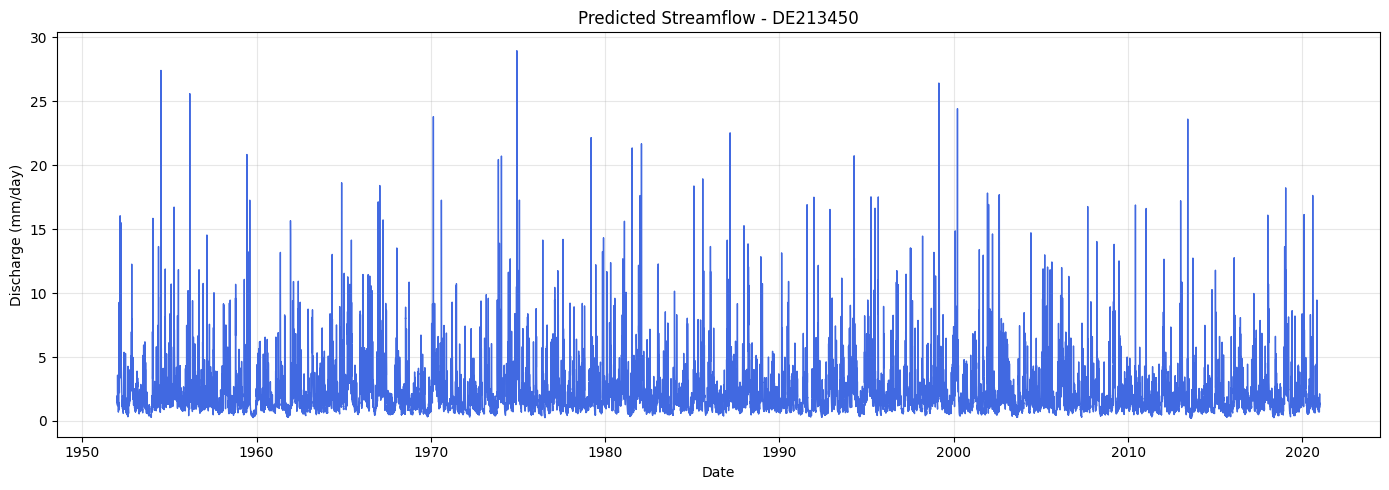

In [ ]:
import matplotlib.pyplot as plt

catchment = catchments[0]

plt.figure(figsize=(14,5))

plt.plot(
    prediction_df["Date"],
    prediction_df[catchment],
    color="royalblue",
    linewidth=1
)

plt.title(f"Predicted Streamflow - {catchment}")

plt.xlabel("Date")

plt.ylabel("Discharge (mm/day)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Summary Statistics

Compute descriptive statistics for the predicted streamflow of each catchment.

In [ ]:
summary = prediction_df.describe().T

summary = summary[
    ["mean","std","min","25%","50%","75%","max"]
]

summary

,mean,std,min,25%,50%,75%,max
Date,1986-07-02 00:00:00,NaN,1952-01-01 00:00:00,1969-04-01 12:00:00,1986-07-02 00:00:00,2003-10-01 12:00:00,2020-12-31 00:00:00
DE213450,2.090934,1.930011,0.202108,0.960332,1.518585,2.491913,28.958385
DE210720,1.805053,1.415209,0.229621,0.949213,1.402252,2.18063,24.704966
DE213560,0.685796,0.573805,-0.038174,0.337117,0.536092,0.85519,14.507639
DE110570,1.024659,1.063837,-0.020915,0.404385,0.717017,1.259953,22.150179
DEA11090,0.70212,0.644132,-0.043207,0.285838,0.518202,0.91635,13.079556
DE214090,0.860433,0.852678,-0.039129,0.324857,0.60672,1.096332,12.976127
DE411220,0.250396,0.246195,-0.073255,0.098735,0.191482,0.328153,6.880337
DEA10160,1.106025,1.077359,-0.024897,0.4183,0.779796,1.412791,17.372501
DE810570,0.332732,0.289676,-0.054658,0.143817,0.255262,0.438752,5.087174


Selecting a Hydrologicaly extreme Year

Convert the Date column to datetime format and identify the available years for plotting.

In [ ]:
prediction_df["Date"] = pd.to_datetime(prediction_df["Date"])

print(
    prediction_df["Date"].dt.year.unique()
)

[1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963 1964 1965
 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979
 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]


Extracting a Representative Year

A year that contains both high-flow and low-flow conditions for visualization.

In [ ]:
#Selected year

YEAR = 2013

pred_year = prediction_df[
    prediction_df["Date"].dt.year == YEAR
]

Plotting Hydrographs for All Ungauged Catchments

Generate hydrographs showing the predicted daily streamflow for every ungauged catchment during the selected year.

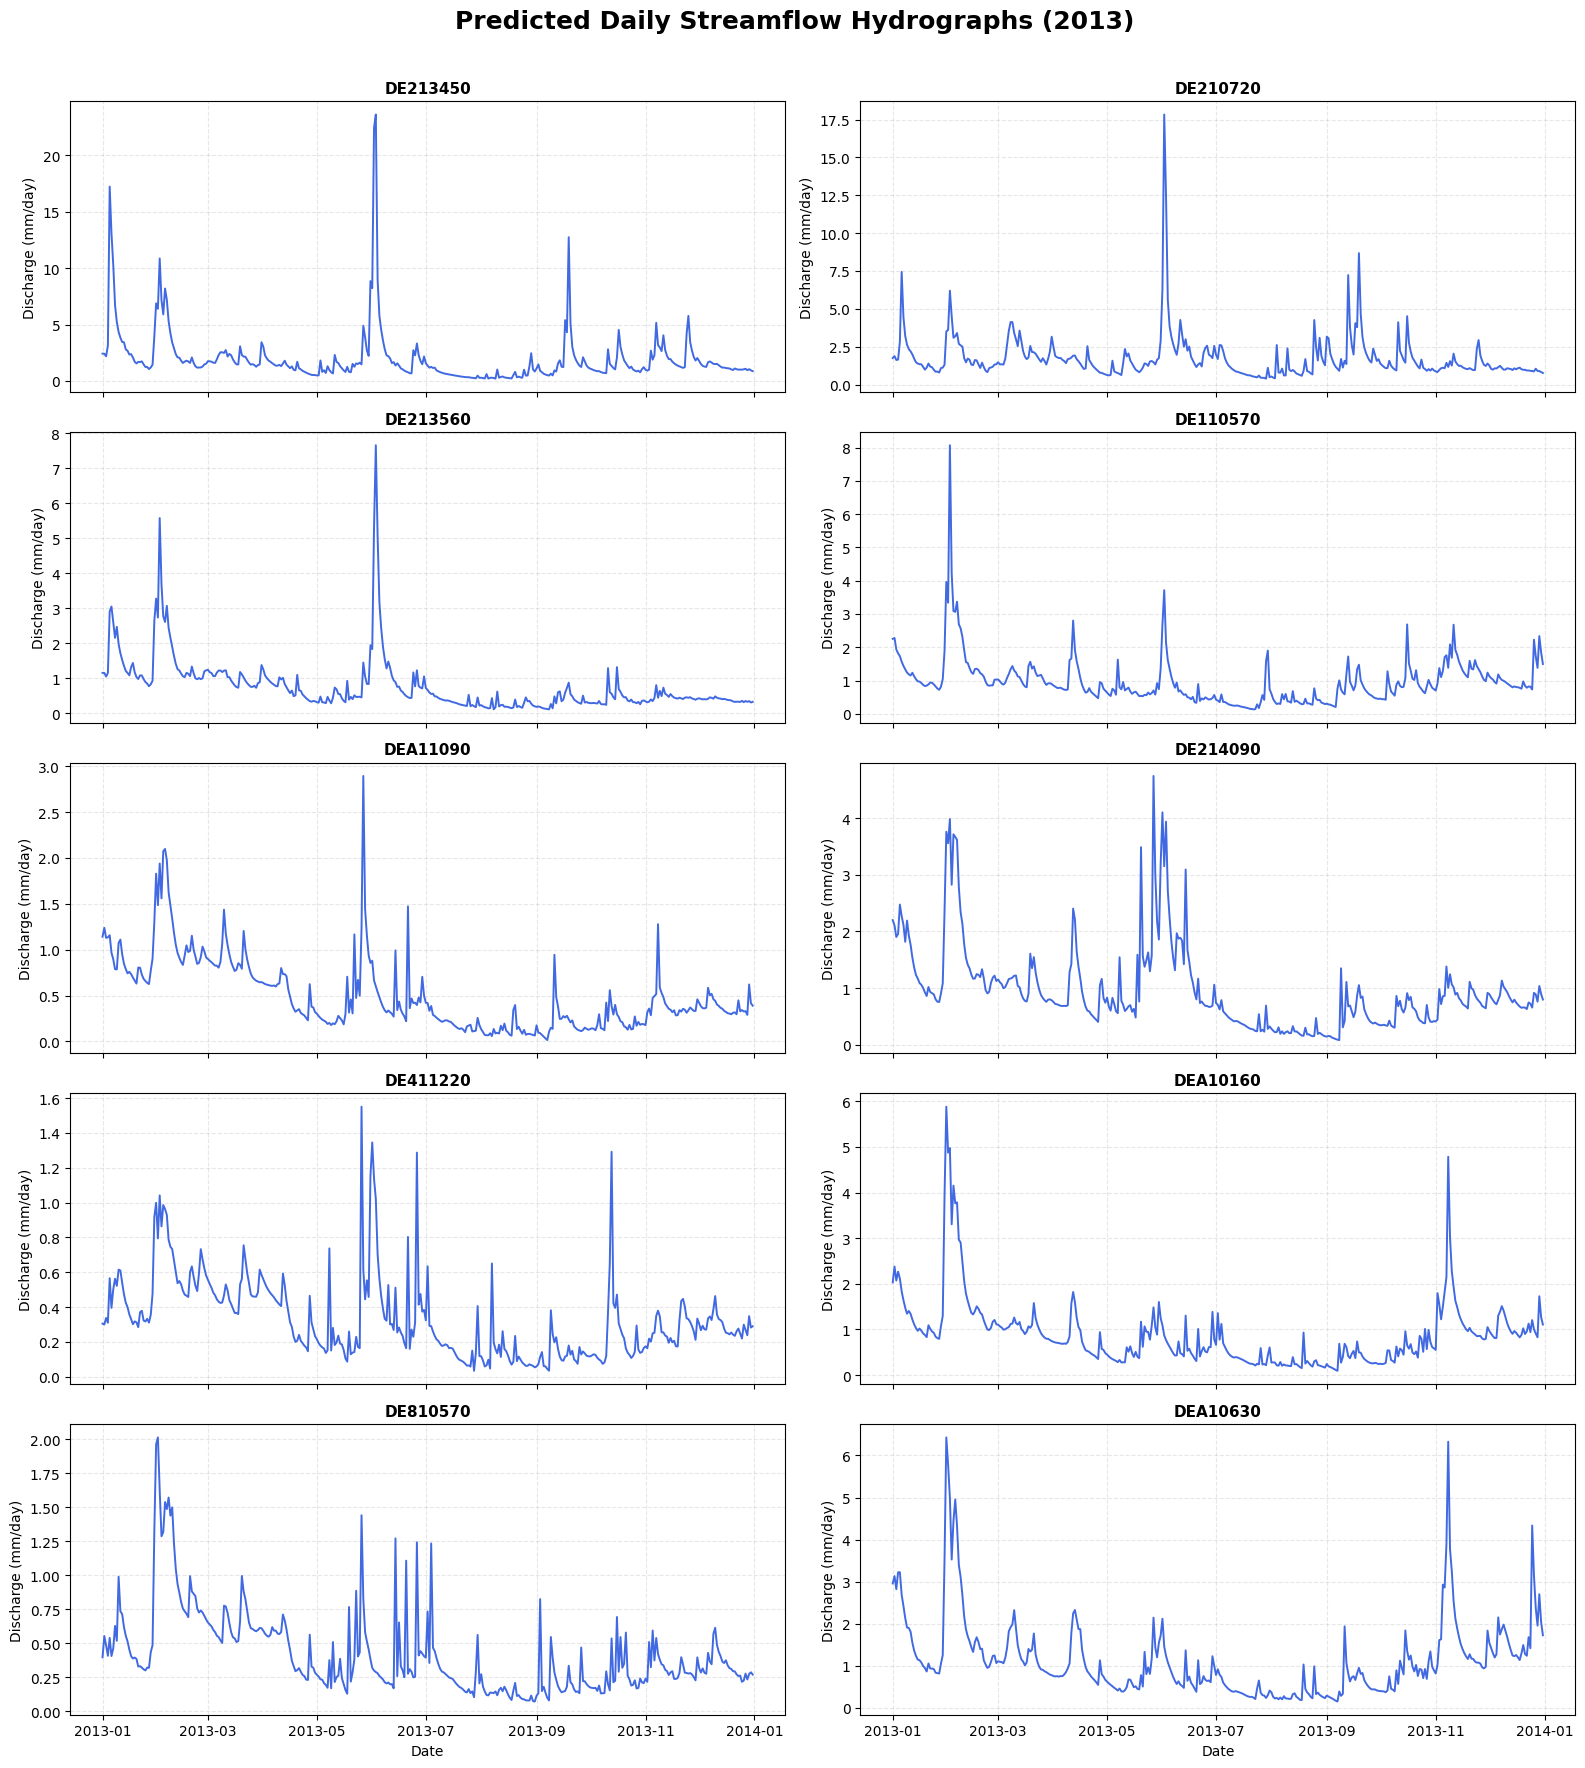

In [ ]:
import matplotlib.pyplot as plt

catchments = prediction_df.columns[1:]

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(16,18),
    sharex=True
)

axes = axes.flatten()

for ax, catchment in zip(axes, catchments):

    ax.plot(
        pred_year["Date"],
        pred_year[catchment],
        color="royalblue",
        linewidth=1.4
    )

    ax.set_title(
        catchment,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_ylabel("Discharge (mm/day)")

    ax.grid(
        alpha=0.3,
        linestyle="--"
    )

for ax in axes[-2:]:

    ax.set_xlabel("Date")

plt.suptitle(
    f"Predicted Daily Streamflow Hydrographs ({YEAR})",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.97])

plt.savefig(
    f"Predicted_Hydrographs_{YEAR}.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ***********